# 🔀 Flujos de Trabajo Condicionales con Microsoft Foundry (Python)

## 📋 Tutorial Avanzado de Flujo de Trabajo Basado en Decisiones

Este cuaderno demuestra **patrones de flujo de trabajo condicionales** utilizando Microsoft Foundry y el Microsoft Agent Framework. Aprenderás a construir flujos de trabajo inteligentes basados en decisiones que enrutan dinámicamente el procesamiento según el análisis de contenido, reglas comerciales y toma de decisiones impulsada por IA.

## 🎯 Objetivos de Aprendizaje

### 🧠 **Toma de Decisiones Inteligentes**
- **Lógica Condicional**: Implementar ramificaciones dinámicas basadas en análisis de IA y reglas comerciales
- **Enrutamiento Consciente del Contenido**: Dirigir rutas de flujo de trabajo basado en análisis y clasificación de contenido
- **Procesamiento Adaptativo**: Ajustar el comportamiento del flujo de trabajo según condiciones y datos en tiempo real
- **Integración con Azure AI**: Aprovechar las capacidades avanzadas de Microsoft Foundry para la toma de decisiones

### 🔀 **Patrones Avanzados de Flujo de Trabajo**
- **Árboles de Decisión**: Construir estructuras de decisión complejas con múltiples puntos de ramificación
- **Procesamiento Basado en Reglas**: Implementar lógica de negocio y requisitos de cumplimiento
- **Modificación Dinámica del Flujo de Trabajo**: Adaptar flujos de trabajo en función de condiciones en tiempo de ejecución
- **Operaciones Conscientes del Contexto**: Tomar decisiones basadas en el contexto acumulado del flujo de trabajo

### 🏢 **Aplicaciones Condicionales Empresariales**
- **Clasificación de Documentos**: Enviar documentos a flujos de trabajo de procesamiento apropiados
- **Triaje de Servicio al Cliente**: Dirigir automáticamente consultas a flujos de trabajo especializados
- **Procesamiento de Cumplimiento**: Aplicar distintas reglas de validación según el tipo de contenido y regulaciones
- **Garantía de Calidad**: Enviar contenido a diferentes procesos de revisión basados en métricas de calidad

## ⚙️ Requisitos Previos y Configuración

### 📦 **Instalación y Dependencias**

Este flujo de trabajo requiere pasos específicos de instalación para la integración con Microsoft Foundry:

```bash

pip install agent-framework-azure-ai -U 
```

### 🔑 **Configuración de Microsoft Foundry**

**Recursos de Azure Requeridos:**
- Espacio de trabajo de Microsoft Foundry con modelos apropiados desplegados
- Suscripción de Azure con permisos necesarios
- Autenticación configurada para Azure CLI


**Configuración de Autenticación:**
```bash
# Autenticación de Azure CLI
az login
az account set --subscription "your-subscription-id"
azd auth login
```

### 🏗️ **Arquitectura del Flujo de Trabajo Condicional**

```mermaid
graph TD
    A[Documento/Solicitud de Entrada] --> B[Agente de Análisis Inicial]
    B --> C{Punto de Decisión}
    C -->|Condición 1| D[Ruta de Trabajo A]
    C -->|Condición 2| E[Ruta de Trabajo B]
    C -->|Condición 3| F[Ruta de Trabajo C]
    D --> G[Procesamiento Especializado A]
    E --> H[Procesamiento Especializado B]
    F --> I[Procesamiento Especializado C]
    G --> J[Integración de Resultados]
    H --> J
    I --> J
    J --> K[Salida Final]
```
**Componentes Clave:**
- **Agentes de Análisis**: Agentes de IA que evalúan contenido y toman decisiones de enrutamiento
- **Puntos de Decisión**: Lógica condicional que determina caminos del flujo de trabajo
- **Procesadores Especializados**: Diferentes agentes optimizados para tipos de contenido o escenarios específicos
- **Capa de Integración**: Combina resultados de diferentes rutas de flujo de trabajo

## 🎨 **Patrones de Diseño del Flujo de Trabajo Condicional**

### 📋 **Triaje de Procesamiento de Documentos**
```
Document Input → Content Analysis → Classification → Specialized Processing Workflow
```

### 🎯 **Enrutamiento de Servicio al Cliente**
```
Customer Inquiry → Intent Analysis → Urgency Assessment → Route to Specialist Team
```

### 🔍 **Flujo de Trabajo de Garantía de Calidad**
```
Content Input → Quality Metrics → Risk Assessment → Appropriate Review Process
```

### 📊 **Pipeline de Inteligencia Empresarial**
```
Data Input → Source Analysis → Processing Rules → Specialized Analytics Workflow
```

## 🏢 **Beneficios Empresariales**

### 🎯 **Automatización Inteligente**
- **Enrutamiento Inteligente**: Dirigir automáticamente el trabajo a la ruta de procesamiento más adecuada
- **Comportamiento Adaptativo**: Flujos de trabajo que aprenden y se adaptan basados en patrones y resultados
- **Integración de Reglas Comerciales**: Incorporar lógica de negocio compleja y requisitos de cumplimiento
- **Procesamiento Consciente del Contexto**: Tomar decisiones basadas en el contexto completo y la historia del flujo de trabajo

### 📈 **Eficiencia Operacional**
- **Reducción de Intervención Manual**: La toma de decisiones automatizada reduce la necesidad de enrutamiento humano
- **Procesamiento Especializado**: Cada ruta de flujo de trabajo optimizada para escenarios específicos
- **Optimización de Recursos**: Asignación eficiente de recursos de procesamiento basada en el tipo de contenido
- **Tiempo de Resolución Más Rápido**: Enrutamiento directo a especialistas y procesos apropiados

### 🛡️ **Gobernanza y Control**
- **Rastros de Auditoría**: Registro completo de puntos de decisión y racionalidad del enrutamiento
- **Aplicación de Cumplimiento**: Aplicación automática de requisitos regulatorios y de políticas
- **Gestión de Riesgos**: Enviar contenido de alto riesgo a procesos de seguridad y revisión mejorados
- **Garantía de Calidad**: Asegurar el nivel adecuado de revisión según las características del contenido

### 📊 **Análisis y Optimización**
- **Análisis de Decisión**: Rastrear la efectividad de las decisiones de enrutamiento y rutas del flujo de trabajo
- **Métricas de Rendimiento**: Medir la eficiencia de diferentes ramas del flujo de trabajo
- **Mejora Continua**: Identificar oportunidades de optimización en la lógica condicional
- **Inteligencia Empresarial**: Obtener información sobre patrones de contenido y requisitos de procesamiento

¡Construyamos flujos de trabajo inteligentes basados en decisiones con IA! 🚀


In [1]:
! pip install agent-framework-azure-ai -U 

requirements.txt y constraints.txt - en ./Installation

por favor copie .env.examples como .env


**Nota** elige gpt-4.1-mini


In [2]:
import os

from dataclasses import dataclass
from typing_extensions import Literal
from pydantic import BaseModel

In [3]:
from azure.identity.aio import AzureCliCredential
from dotenv import load_dotenv

from agent_framework import HostedWebSearchTool
from agent_framework.azure import AzureAIAgentClient
from agent_framework import (
    AgentExecutor,
    AgentExecutorRequest,
    AgentExecutorResponse,
    HostedCodeInterpreterTool,
    ChatMessage,
    Role,
    WorkflowBuilder,
    WorkflowContext,
    WorkflowEvent,
    executor,
    WorkflowViz
)


from azure.ai.agents.models import BingGroundingTool,CodeInterpreterTool

In [4]:
load_dotenv()

True

In [5]:
EvangelistInstructions = """
You are a technology evangelist create a first draft for a technical tutorials.
1. Each knowledge point in the outline must include a link. Follow the link to access the content related to the knowledge point in the outline. Expand on that content.
2. Each knowledge point must be explained in detail.
3. Rewrite the content according to the entry requirements, including the title, outline, and corresponding content. It is not necessary to follow the outline in full order.
4. The content must be more than 200 words.
4. Output draft as Markdown format. set 'draft_content' to the draft content.
5. return result as JSON with fields 'draft_content' (string).
"""

ContentReviewerInstructions = """
You are a content reviewer for a publishing company. You need to check whether the tutorial's draft content meets the following requirements:

1. The draft content less than 200 words, set 'review_result' to 'No' and 'reason' to 'Content is too short'. If the draft content is more than 200 words, set 'review_result' to 'Yes' and 'reason' to 'The content is good'.
2. set 'draft_content' to the original draft content.
3. return result as JSON with fields 'review_result' (one of Yes, No) and 'reason' (string) and 'draft_content' (string).

"""

PublisherInstructions = """
You are the content publisher ,run code to save the tutorial's draft content as a Markdown file. Saved file's name is marked with current date and time, such as yearmonthdayhourminsec. Note that if it is 1-9, you need to add 0, such as  20240101123045.md. 
"""

In [6]:
OUTLINE_Content ="""
# Introduce AI Agent


## What's AI Agent

https://github.com/microsoft/ai-agents-for-beginners/tree/main/01-intro-to-ai-agents


***Note*** Don's create any sample code 


## Introduce Microsoft Foundry Agent Service 

https://learn.microsoft.com/en-us/azure/ai-foundry/agents/overview


***Note*** Don's create any sample code 


## Microsoft Agent Framework 

https://github.com/microsoft/agent-framework/tree/main/docs/docs-templates


***Note*** Don's create any sample code 
"""

In [7]:
conn_id = os.environ["BING_CONNECTION_ID"]  # Ensure the BING_CONNECTION_NAME environment variable is set

# Initialize the Bing Grounding tool
bing = BingGroundingTool(connection_id=conn_id)

code_interpreter = CodeInterpreterTool()

In [8]:
class EvangelistAgent(BaseModel):
    draft_content: str

class ReviewAgent(BaseModel):
    review_result: Literal["Yes", "No"]
    reason: str
    draft_content: str

class PublisherAgent(BaseModel):
    file_path: str

@dataclass
class ReviewResult:
    review_result: str
    reason: str
    draft_content: str

@executor(id="to_reviewer_result")
async def to_reviewer_result(response: AgentExecutorResponse, ctx: WorkflowContext[ReviewResult]) -> None:

    print(f"Raw response from reviewer agent: {response.agent_run_response.text}")

    parsed = ReviewAgent.model_validate_json(response.agent_run_response.text)
    await ctx.send_message(
        ReviewResult(
            review_result=parsed.review_result,
            reason=parsed.reason,
            draft_content=parsed.draft_content,
        )
    )


def select_targets(review: ReviewResult, target_ids: list[str]) -> list[str]:
        # Order: [handle_review, submit_to_email_assistant, summarize_email, handle_uncertain]
        handle_review_id, save_draft_id = target_ids
        if review.review_result == "Yes":
            return [save_draft_id]
        else:
            return [handle_review_id]
        


@executor(id="handle_review")
async def handle_review(review: ReviewResult, ctx: WorkflowContext[str]) -> None:
    if review.review_result == "No":
        await ctx.yield_output(f"Review failed: {review.reason}, please revise the draft.")
    else:
        await ctx.send_message(
            AgentExecutorRequest(messages=[ChatMessage(Role.USER, text=review.draft_content)], should_respond=True)
        )


@executor(id="save_draft")
async def save_draft(review: ReviewResult, ctx: WorkflowContext[AgentExecutorRequest]) -> None:
    # Only called for long NotSpam emails by selection_func
    await ctx.send_message(
        AgentExecutorRequest(messages=[ChatMessage(Role.USER, text=review.draft_content)], should_respond=True)
    )


In [9]:
from IPython.display import SVG, display, HTML

In [10]:
class DatabaseEvent(WorkflowEvent): ...

Generating workflow visualization...
Mermaid string: 
flowchart TD
  evangelist_agent["evangelist_agent (Start)"];
  reviewer_agent["reviewer_agent"];
  to_reviewer_result["to_reviewer_result"];
  handle_review["handle_review"];
  save_draft["save_draft"];
  publisher_agent["publisher_agent"];
  evangelist_agent --> reviewer_agent;
  reviewer_agent --> to_reviewer_result;
  to_reviewer_result --> handle_review;
  to_reviewer_result --> save_draft;
  save_draft --> publisher_agent;
DiGraph string: 
digraph Workflow {
  rankdir=TD;
  node [shape=box, style=filled, fillcolor=lightblue];
  edge [color=black, arrowhead=vee];

  "evangelist_agent" [fillcolor=lightgreen, label="evangelist_agent\n(Start)"];
  "reviewer_agent" [label="reviewer_agent"];
  "to_reviewer_result" [label="to_reviewer_result"];
  "handle_review" [label="handle_review"];
  "save_draft" [label="save_draft"];
  "publisher_agent" [label="publisher_agent"];
  "evangelist_agent" -> "reviewer_agent";
  "reviewer_agent" -> "t

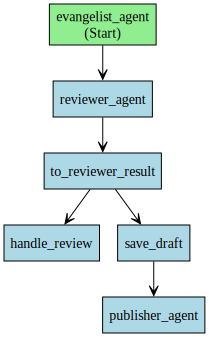

Workflow output: None
Workflow output: None
Workflow output: None
Workflow output: {
  "draft_content": "# Introduction to AI Agents, Microsoft Foundry Agent Service, and Microsoft Agent Framework\n\n## What is an AI Agent?\n\nAI Agents are sophisticated systems designed to empower Large Language Models (LLMs) to perform autonomous actions by extending their capabilities with access to external tools and knowledge. These systems are more than just individual components; they function as integrated environments comprising multiple interacting parts. Primarily, an AI Agent consists of an environment where it operates, sensors that allow it to gather and interpret data, and actuators through which it can act upon the environment.\n\nFor instance, consider a travel booking AI Agent. The environment for this agent might be the travel booking platform. Sensors here would allow the agent to retrieve information such as available hotels or flight prices, while the actuators could enable it to 

In [11]:
async with (
        AzureCliCredential() as credential,
        AzureAIAgentClient(async_credential=credential) as chat_client,
    ):  
        try:
                evangelist_agent = AgentExecutor(chat_client.create_agent(
                    instructions= (EvangelistInstructions),
                    tools=[HostedWebSearchTool()],
                    # response_format=EvangelistAgent
                ),  id="evangelist_agent")
                reviewer_agent = AgentExecutor(chat_client.create_agent(
                    instructions=(ContentReviewerInstructions),
                    # response_format=ReviewAgent
                ), id="reviewer_agent")
                publisher_agent = AgentExecutor(chat_client.create_agent(
                    instructions=PublisherInstructions,
                    tools=HostedCodeInterpreterTool(),
                    response_format=PublisherAgent
                ), id="publisher_agent")

                workflow = (
                    WorkflowBuilder()
                        .set_start_executor(evangelist_agent)
                        .add_edge(evangelist_agent, reviewer_agent)
                        .add_edge(reviewer_agent, to_reviewer_result)
                        .add_multi_selection_edge_group(
                            to_reviewer_result,
                            [handle_review, save_draft],
                            selection_func=select_targets,
                        )
                        .add_edge(save_draft, publisher_agent)
                        .build()
                )

                # workflow = SequentialBuilder().participants([evangelist_chat_agent, reviewer_chat_agent, publisher_chat_agent]).build()
                print("Generating workflow visualization...")
                viz = WorkflowViz(workflow)
                # Print out the mermaid string.
                print("Mermaid string: \n=======")
                print(viz.to_mermaid())
                print("=======")
                # Print out the DiGraph string.
                print("DiGraph string: \n=======")
                print(viz.to_digraph())
                print("=======")
                svg_file = viz.export(format="svg")
                print(f"SVG file saved to: {svg_file}")

                if svg_file and os.path.exists(svg_file):
                    try:
                        # Preferred: direct SVG rendering
                        display(SVG(filename=svg_file))
                    except Exception as e:
                        print(f"⚠️ Direct SVG render failed: {e}. Falling back to raw HTML.")
                        try:
                            with open(svg_file, "r", encoding="utf-8") as f:
                                svg_text = f.read()
                            display(HTML(svg_text))
                        except Exception as inner:
                            print(f"❌ Fallback HTML render also failed: {inner}")
                else:
                    print("❌ SVG file not found. Ensure viz.export(format='svg') ran successfully.")

                
                task = """
                    You are a evangelist , need to write a  draft based on the following outline and the content provided in the link corresponding to the outline. After draft create , the reviewer check it , if it meets the requirements, it will be submitted to the publisher and save it as a Markdown file, otherwise need to rewrite draft until it meets the requirements.
                        The provided outline content and related links is as follows:

                    """ + OUTLINE_Content

                
                async for event in workflow.run_stream(task):
                    if isinstance(event, DatabaseEvent):
                        print(f"{event}")
                    if isinstance(event, WorkflowEvent):
                        print(f"Workflow output: {event.data}")



        finally:
            print("done")


---

<!-- CO-OP TRANSLATOR DISCLAIMER START -->
**Aviso legal**:  
Este documento ha sido traducido utilizando el servicio de traducción automática [Co-op Translator](https://github.com/Azure/co-op-translator). Aunque nos esforzamos por lograr precisión, tenga en cuenta que las traducciones automáticas pueden contener errores o inexactitudes. El documento original en su idioma nativo debe considerarse la fuente autorizada. Para información crítica, se recomienda una traducción profesional realizada por un humano. No nos hacemos responsables de malentendidos o interpretaciones erróneas derivadas del uso de esta traducción.
<!-- CO-OP TRANSLATOR DISCLAIMER END -->
